# Arabic Medical QA - Model Comparison

**Task:** Arabic Medical Question Answering (37-class classification)

**Models:**
1. Baseline: TF-IDF + Logistic Regression
2. AraBERTv2 (Reproduction of original paper)
3. CAMeL-BERT (LLM Comparison)

**Dataset:** Arabic Medical Q&A Dataset (Kaggle)

## 1. Setup: GPU, Drive & Libraries

In [ ]:
import tensorflow as tf
print("TF Version:", tf.__version__)

device_name = tf.test.gpu_device_name()
print('Found GPU at: {}'.format(device_name) if device_name == '/device:GPU:0' else 'Running on CPU')
!nvidia-smi

TF Version: 2.20.0
Found GPU at: /device:GPU:0
Thu May 14 19:32:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P0             26W /   70W |     105MiB /  15360MiB |      3%      Default |
|                                         |                        |                  N/A |
+

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install transformers datasets arabert pyarabic farasapy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 10.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 6.5 MB/s eta 0:00:00


## 2. Load Dataset

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np

data_path = "/content/drive/MyDrive/Arabic_Medical _Q&A"

# Load CLEAN data (after exploration & cleaning notebook)
raw_datasets = load_dataset('csv', data_files={
    'train':      f'{data_path}/train_clean.csv',
    'validation': f'{data_path}/val_clean.csv',
    'test':       f'{data_path}/test_clean.csv'
})

print(raw_datasets)
df_preview = pd.DataFrame(raw_datasets['train'].select(range(5)))
display(df_preview)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'label'],
        num_rows: 24499
    })
    validation: Dataset({
        features: ['question', 'answer', 'label'],
        num_rows: 10596
    })
    test: Dataset({
        features: ['question', 'answer', 'label'],
        num_rows: 10505
    })
})


,question,answer,label
0,\nما حقيقة ان تمرين العضلة النعلية يخفض السكر ...,\n\nإذا قصدت تدليك العضلة فهذا كلام غير صحيح ....,مرض_السكري
1,\nهل المشي بعد الأكل مباشرةً لمدة نصف ساعة مضر...,\n\nلا ينصح بممارسة الرياضة بعد الأكل مباشرة\n...,امراض_الغدد_الصماء
2,\nلدي تضخم في الثدي الايسر من دون الم منذ ثلاث...,\n\nلا بد من مراجعة اخصائي الجراحة العامة\n0\n...,امراض_الغدد_الصماء
3,\nعملت فحص تحليل مقاومه الانسولين وكانت النتيج...,\n\nالتحاليل طبيعية . اذا كان وزنك زائدا فتوقع...,امراض_الغدد_الصماء
4,\nكيف نقوم با التعامل مع اختى ذات ال17 عام وهى...,\n\nشقيقتك مصابة بالسكر من النوع الأول إذا لا ...,مرض_السكري


## 3. Text Cleaning & Label Encoding

In [ ]:
import re
import torch
import pyarabic.araby as arab
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

def clean_sentence(text):
    if not isinstance(text, str):
        return ""
    text = arab.strip_tashkeel(text)
    text = arab.strip_tatweel(text)
    text = re.sub(r"https?:\/\/.*[\r\n]*", " ", text, flags=re.MULTILINE)
    text = re.sub(r"[A-Za-z0-9\n\.\،\(\)\{\}\[\] \\ /+_=%$#@!:;\-*&\'^`|~]", " ", text, flags=re.UNICODE)
    text = re.sub("[\u0625\u0623\u0622\u0671]", "\u0627", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Convert to DataFrames
train_df = pd.DataFrame(raw_datasets['train'])
val_df   = pd.DataFrame(raw_datasets['validation'])
test_df  = pd.DataFrame(raw_datasets['test'])

# Clean text
for df in [train_df, val_df, test_df]:
    df['question_clean'] = df['question'].apply(clean_sentence)
    df['answer_clean']   = df['answer'].apply(clean_sentence)
    df['text']           = df['question_clean'] + " [SEP] " + df['answer_clean']

# Encode labels
le = LabelEncoder()
le.fit(train_df['label'])
num_labels = len(le.classes_)
print(f"Number of labels: {num_labels}")
print(f"Labels: {le.classes_}")

for df in [train_df, val_df, test_df]:
    df['label_encoded'] = le.transform(df['label'])

# Compute Class Weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_encoded']),
    y=train_df['label_encoded']
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"\nClass weights computed for {len(class_weights)} classes")
print(f"Min weight: {class_weights.min():.3f} | Max weight: {class_weights.max():.3f}")
print(f"\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

Number of labels: 8
Labels: ['ارتفاع_ضغط_الدم' 'الاورام_الخبيثة_والحميدة' 'امراض_الجهاز_التنفسي'
 'امراض_الدم' 'امراض_الغدد_الصماء' 'جراحة_العظام' 'جراحة_عامة'
 'مرض_السكري']

Class weights computed for 8 classes
Min weight: 0.634 | Max weight: 3.014

Train: 24,499 | Val: 10,596 | Test: 10,505


## 4. Model 1: Baseline — TF-IDF + Logistic Regression

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

print("Training Baseline (TF-IDF + Logistic Regression)...")
start = time.time()

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), analyzer='char_wb')
X_train_tfidf = tfidf.fit_transform(train_df['text'])
X_val_tfidf   = tfidf.transform(val_df['text'])
X_test_tfidf  = tfidf.transform(test_df['text'])

y_train = train_df['label_encoded']
y_test  = test_df['label_encoded']

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', multi_class='multinomial')
lr_model.fit(X_train_tfidf, y_train)

elapsed = time.time() - start
print(f"Training done in {elapsed:.1f}s")

# Evaluate
y_pred_baseline = lr_model.predict(X_test_tfidf)

baseline_acc  = accuracy_score(y_test, y_pred_baseline)
baseline_f1w  = f1_score(y_test, y_pred_baseline, average='weighted', zero_division=0)
baseline_f1m  = f1_score(y_test, y_pred_baseline, average='macro',    zero_division=0)

print(f"\n=== Baseline Results ===")
print(f"Accuracy:    {baseline_acc:.4f}")
print(f"F1-Weighted: {baseline_f1w:.4f}")
print(f"F1-Macro:    {baseline_f1m:.4f}")

print("\nClassification Report:")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_pred_baseline),
    zero_division=0
))

Training Baseline (TF-IDF + Logistic Regression)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training done in 34.7s

=== Baseline Results ===
Accuracy:    0.7273
F1-Weighted: 0.7267
F1-Macro:    0.7161

Classification Report:
                          precision    recall  f1-score   support

         ارتفاع_ضغط_الدم       0.72      0.73      0.73       864
الاورام_الخبيثة_والحميدة       0.73      0.74      0.74      1985
    امراض_الجهاز_التنفسي       0.70      0.71      0.70      1221
              امراض_الدم       0.68      0.54      0.60       431
      امراض_الغدد_الصماء       0.75      0.71      0.73      1853
            جراحة_العظام       0.74      0.77      0.76       782
              جراحة_عامة       0.74      0.74      0.74      1986
              مرض_السكري       0.72      0.75      0.73      1383

                accuracy                           0.73     10505
               macro avg       0.72      0.71      0.72     10505
            weighted avg       0.73      0.73      0.73     10505



## 5. Model 2: AraBERTv2 (Reproduction of Original Paper)

In [ ]:
from arabert.preprocess import ArabertPreprocessor
from transformers import AutoTokenizer

arabert_model_name = "aubmindlab/bert-base-arabertv2"
arabert_prep = ArabertPreprocessor(model_name=arabert_model_name, keep_emojis=False)
arabert_tokenizer = AutoTokenizer.from_pretrained(arabert_model_name)

print("AraBERTv2 tokenizer loaded!")

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'farasa-api.qcri.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


100%|██████████| 241M/241M [04:38<00:00, 867kiB/s] 


[2026-05-14 19:40:45,519 - farasapy_logger - WARNING]: Be careful with large lines as they may break on interactive mode. You may switch to Standalone mode for such cases.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

AraBERTv2 tokenizer loaded!


In [ ]:
from datasets import Dataset

def make_hf_dataset(df, prep, tok):
    def preprocess(examples):
        q = [prep.preprocess(t) for t in examples['question_clean']]
        a = [prep.preprocess(t) for t in examples['answer_clean']]
        enc = tok(q, a, truncation=True, padding='max_length', max_length=256)
        enc['label'] = examples['label']  # ← label مش label_encoded
        return enc

    ds = Dataset.from_pandas(
        df[['question_clean','answer_clean','label_encoded']]
        .rename(columns={'label_encoded':'label'})
        .reset_index(drop=True)
    )
    return ds.map(preprocess, batched=True,
                  remove_columns=['question_clean','answer_clean'])

print("Preparing AraBERTv2 datasets...")
arabert_train = make_hf_dataset(train_df, arabert_prep, arabert_tokenizer)
arabert_val   = make_hf_dataset(val_df,   arabert_prep, arabert_tokenizer)
arabert_test  = make_hf_dataset(test_df,  arabert_prep, arabert_tokenizer)
print("Done!")

Preparing AraBERTv2 datasets...


Map:   0%|          | 0/24499 [00:00<?, ? examples/s]

Map:   0%|          | 0/10596 [00:00<?, ? examples/s]

Map:   0%|          | 0/10505 [00:00<?, ? examples/s]

Done!


In [ ]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':    accuracy_score(labels, preds),
        'f1_weighted': f1_score(labels, preds, average='weighted', zero_division=0),
        'f1_macro':    f1_score(labels, preds, average='macro',    zero_division=0)
    }

# Weighted Trainer to handle class imbalance
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fn = torch.nn.CrossEntropyLoss(
            weight=class_weights_tensor.to(model.device)
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

arabert_model = BertForSequenceClassification.from_pretrained(arabert_model_name, num_labels=num_labels)

arabert_args = TrainingArguments(
    output_dir="./results_arabert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    save_total_limit=1,
    fp16=True,
    logging_steps=50,
    logging_dir="./logs_arabert",
)

arabert_trainer = WeightedTrainer(
    model=arabert_model,
    args=arabert_args,
    train_dataset=arabert_train,
    eval_dataset=arabert_val,
    compute_metrics=compute_metrics,
)

print("Training AraBERTv2...")
import datetime
start = datetime.datetime.now()
arabert_trainer.train()
elapsed = datetime.datetime.now() - start
print(f"AraBERTv2 training done in {str(elapsed).split('.')[0]}")

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider

Training AraBERTv2...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.084165,1.708906,0.749056,0.749016,0.746224
2,0.081782,1.821688,0.749811,0.749769,0.747180
3,0.045540,1.874467,0.749528,0.749491,0.746884


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

AraBERTv2 training done in 0:18:06


In [ ]:
arabert_test_results = arabert_trainer.evaluate(eval_dataset=arabert_test)

arabert_preds_out = arabert_trainer.predict(arabert_test)
arabert_preds = np.argmax(arabert_preds_out.predictions, axis=-1)
arabert_true  = arabert_preds_out.label_ids

arabert_acc = accuracy_score(arabert_true, arabert_preds)
arabert_f1w = f1_score(arabert_true, arabert_preds, average='weighted', zero_division=0)
arabert_f1m = f1_score(arabert_true, arabert_preds, average='macro',    zero_division=0)

print(f"=== AraBERTv2 Results ===")
print(f"Accuracy:    {arabert_acc:.4f}")
print(f"F1-Weighted: {arabert_f1w:.4f}")
print(f"F1-Macro:    {arabert_f1m:.4f}")

print("\nClassification Report:")
print(classification_report(
    le.inverse_transform(arabert_true),
    le.inverse_transform(arabert_preds),
    zero_division=0
))

=== AraBERTv2 Results ===
Accuracy:    0.7508
F1-Weighted: 0.7508
F1-Macro:    0.7461

Classification Report:
                          precision    recall  f1-score   support

         ارتفاع_ضغط_الدم       0.74      0.75      0.74       864
الاورام_الخبيثة_والحميدة       0.75      0.75      0.75      1985
    امراض_الجهاز_التنفسي       0.72      0.72      0.72      1221
              امراض_الدم       0.69      0.71      0.70       431
      امراض_الغدد_الصماء       0.77      0.75      0.76      1853
            جراحة_العظام       0.75      0.81      0.78       782
              جراحة_عامة       0.76      0.75      0.75      1986
              مرض_السكري       0.76      0.77      0.76      1383

                accuracy                           0.75     10505
               macro avg       0.74      0.75      0.75     10505
            weighted avg       0.75      0.75      0.75     10505



 Note: Although the model was trained for 3 epochs, the best checkpoint
 was automatically selected from Epoch 1 based on the highest F1-Weighted score.
 This is handled by load_best_model_at_end=True in TrainingArguments.
 Epoch 1 achieved the best generalization before overfitting occurred.

## 6. Model 3: CAMeL-BERT (LLM Comparison)

In [ ]:
from transformers import AutoTokenizer as AT

camel_model_name = "CAMeL-Lab/bert-base-arabic-camelbert-mix"
camel_tokenizer = AT.from_pretrained(camel_model_name)
print("CAMeL-BERT tokenizer loaded!")

config.json:   0%|          | 0.00/468 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

CAMeL-BERT tokenizer loaded!


In [ ]:
def make_hf_dataset_notok(df, tok):
    def preprocess(examples):
        q = examples['question_clean']
        a = examples['answer_clean']
        enc = tok(q, a, truncation=True, padding='max_length', max_length=256)
        enc['label'] = examples['label']
        return enc

    ds = Dataset.from_pandas(df[['question_clean','answer_clean','label_encoded']].rename(
        columns={'label_encoded':'label'}))
    return ds.map(preprocess, batched=True, remove_columns=['question_clean','answer_clean'])

print("Preparing CAMeL-BERT datasets...")
camel_train = make_hf_dataset_notok(train_df, camel_tokenizer)
camel_val   = make_hf_dataset_notok(val_df,   camel_tokenizer)
camel_test  = make_hf_dataset_notok(test_df,  camel_tokenizer)
print("Done!")

Preparing CAMeL-BERT datasets...


Map:   0%|          | 0/24499 [00:00<?, ? examples/s]

Map:   0%|          | 0/10596 [00:00<?, ? examples/s]

Map:   0%|          | 0/10505 [00:00<?, ? examples/s]

Done!


In [ ]:
from transformers import BertForSequenceClassification as BFSC

camel_model = BFSC.from_pretrained(camel_model_name, num_labels=num_labels)

camel_args = TrainingArguments(
    output_dir="./results_camel",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    save_total_limit=1,
    fp16=True,
    logging_steps=50,
    logging_dir="./logs_camel",
)

camel_trainer = WeightedTrainer(
    model=camel_model,
    args=camel_args,
    train_dataset=camel_train,
    eval_dataset=camel_val,
    compute_metrics=compute_metrics,
)

print("Training CAMeL-BERT...")
start = datetime.datetime.now()
camel_trainer.train()
elapsed = datetime.datetime.now() - start
print(f"CAMeL-BERT training done in {str(elapsed).split('.')[0]}")

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; n

Training CAMeL-BERT...


model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

CAMeL-BERT training done in 0:18:11


In [ ]:
camel_preds_out = camel_trainer.predict(camel_test)
camel_preds = np.argmax(camel_preds_out.predictions, axis=-1)
camel_true  = camel_preds_out.label_ids

camel_acc = accuracy_score(camel_true, camel_preds)
camel_f1w = f1_score(camel_true, camel_preds, average='weighted', zero_division=0)
camel_f1m = f1_score(camel_true, camel_preds, average='macro',    zero_division=0)

print(f"=== CAMeL-BERT Results ===")
print(f"Accuracy:    {camel_acc:.4f}")
print(f"F1-Weighted: {camel_f1w:.4f}")
print(f"F1-Macro:    {camel_f1m:.4f}")

print("\nClassification Report:")
print(classification_report(
    le.inverse_transform(camel_true),
    le.inverse_transform(camel_preds),
    zero_division=0
))

=== CAMeL-BERT Results ===
Accuracy:    0.7518
F1-Weighted: 0.7518
F1-Macro:    0.7474

Classification Report:
                          precision    recall  f1-score   support

         ارتفاع_ضغط_الدم       0.74      0.75      0.75       864
الاورام_الخبيثة_والحميدة       0.75      0.75      0.75      1985
    امراض_الجهاز_التنفسي       0.72      0.72      0.72      1221
              امراض_الدم       0.69      0.71      0.70       431
      امراض_الغدد_الصماء       0.77      0.75      0.76      1853
            جراحة_العظام       0.75      0.81      0.78       782
              جراحة_عامة       0.76      0.75      0.76      1986
              مرض_السكري       0.76      0.77      0.76      1383

                accuracy                           0.75     10505
               macro avg       0.74      0.75      0.75     10505
            weighted avg       0.75      0.75      0.75     10505



## 7. Final Comparison & Visualization

FINAL COMPARISON - Arabic Medical QA (37 classes)


,Accuracy,F1-Weighted,F1-Macro
Model,,,
Baseline\n(TF-IDF + LR),0.727273,0.726724,0.716071
AraBERTv2\n(Reproduction),0.750785,0.750773,0.746098
CAMeL-BERT\n(LLM),0.751832,0.751817,0.747433


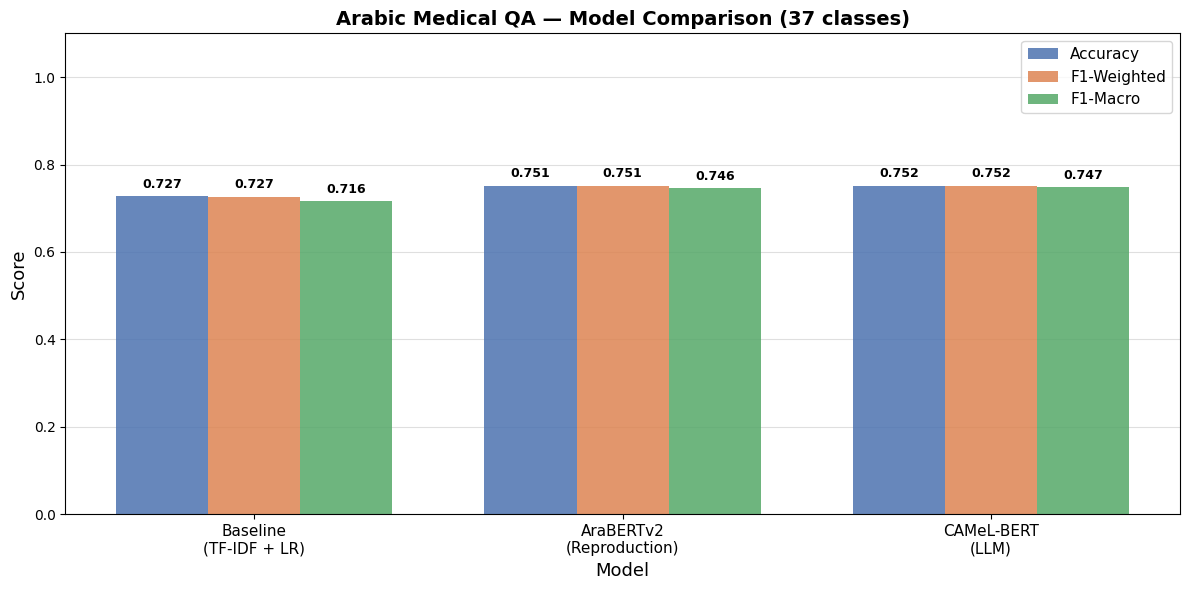

Chart saved to Drive!


In [ ]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Results table
results = {
    'Model':       ['Baseline\n(TF-IDF + LR)', 'AraBERTv2\n(Reproduction)', 'CAMeL-BERT\n(LLM)'],
    'Accuracy':    [baseline_acc,  arabert_acc,  camel_acc],
    'F1-Weighted': [baseline_f1w,  arabert_f1w,  camel_f1w],
    'F1-Macro':    [baseline_f1m,  arabert_f1m,  camel_f1m],
}

results_df = pd.DataFrame(results)
print("=" * 55)
print("FINAL COMPARISON - Arabic Medical QA (37 classes)")
print("=" * 55)
display(results_df.set_index('Model'))

# ---- Bar Chart ----
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results['Model']))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

bars1 = ax.bar(x - width, results['Accuracy'],    width, label='Accuracy',    color=colors[0], alpha=0.85)
bars2 = ax.bar(x,          results['F1-Weighted'], width, label='F1-Weighted', color=colors[1], alpha=0.85)
bars3 = ax.bar(x + width,  results['F1-Macro'],    width, label='F1-Macro',    color=colors[2], alpha=0.85)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Arabic Medical QA — Model Comparison (37 classes)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Arabic_Medical _Q&A/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to Drive!")

## 8. Save Best Model to Drive

In [ ]:
import pickle

# Save AraBERTv2
arabert_save = "/content/drive/MyDrive/Arabic_Medical _Q&A/arabert_model"
arabert_trainer.save_model(arabert_save)
arabert_tokenizer.save_pretrained(arabert_save)

# Save CAMeL-BERT
camel_save = "/content/drive/MyDrive/Arabic_Medical _Q&A/camel_model"
camel_trainer.save_model(camel_save)
camel_tokenizer.save_pretrained(camel_save)

# Save Label Encoder (shared)
with open(f"{arabert_save}/label_encoder.pkl", 'wb') as f:
    pickle.dump(le, f)

print("All models saved to Drive!")
print(f"AraBERTv2 -> {arabert_save}")
print(f"CAMeL-BERT -> {camel_save}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All models saved to Drive!
AraBERTv2 -> /content/drive/MyDrive/Arabic_Medical _Q&A/arabert_model
CAMeL-BERT -> /content/drive/MyDrive/Arabic_Medical _Q&A/camel_model


In [5]:
import nbformat

file_path = "/content/02_Modeling.ipynb"

with open(file_path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

nb.metadata.pop("widgets", None)

for cell in nb.cells:
    if "metadata" in cell:
        cell["metadata"].pop("widgets", None)

with open(file_path, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("Widgets metadata removed completely")

Widgets metadata removed completely
